# 01 — DStroke training data synthesis

Paper reference: Fu et al. 2021, *Fast Accurate and Automatic Brushstroke Extraction*, §3.1 (Algorithm 1).

Pipeline:

1. **Step 0a** — extract all KyleBrush `.abr` files under `data_notcommitted/` into grayscale PNGs using pure Python (based on [ZZYZX/abr2png](https://github.com/ZZYZX/abr2png)).
2. **[Manual]** curate a subset of those PNGs into `brushes/curated/` (stroke-shaped brushes only; skip stamps/textures).
3. **Step 0b** — unzip the Art500K `toy_dataset.zip` (Web Gallery of Art subset) if not already extracted.
4. Sample 500 painting images, filter to oil/tempera/watercolor works.
5. Run `synthesize_painting(...)` on each → produce `(painting, edge_map)` pairs.
6. Save pairs under `data_notcommitted/dstroke_synth/{train,val}/` (90/10 split).
7. Visual sanity check on 10 random pairs.

In [3]:
from __future__ import annotations
import os, sys, zipfile, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# make dstroke_utils importable (notebook lives next to it)
NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR))
import dstroke_utils as d

REPO_ROOT = Path(r'C:\Users\chell\Repos\Work\AiA-Fingerprinting')
DATA_NC = REPO_ROOT / 'data_notcommitted'

BRUSHES_RAW = NB_DIR / 'brushes' / '_raw'
BRUSHES_CURATED = NB_DIR / 'brushes' / 'curated'

ART500K_DIR = DATA_NC / 'art500k'
TOY_ZIP = ART500K_DIR / 'toy_dataset.zip'
TOY_IMG_DIR = ART500K_DIR / 'toy_dataset'
TOY_LABEL = ART500K_DIR / 'toy_dataset_label.csv'

SYNTH_OUT = DATA_NC / 'dstroke_synth'

print('Brushes raw dir:   ', BRUSHES_RAW)
print('Brushes curated:   ', BRUSHES_CURATED)
print('Art500K zip:       ', TOY_ZIP, 'exists:', TOY_ZIP.exists())
print('Art500K extracted: ', TOY_IMG_DIR, 'exists:', TOY_IMG_DIR.exists())
print('Synthetic out:     ', SYNTH_OUT)

Brushes raw dir:    c:\Users\chell\Repos\Work\AiA-Fingerprinting\research\dstroke\brushes\_raw
Brushes curated:    c:\Users\chell\Repos\Work\AiA-Fingerprinting\research\dstroke\brushes\curated
Art500K zip:        C:\Users\chell\Repos\Work\AiA-Fingerprinting\data_notcommitted\art500k\toy_dataset.zip exists: True
Art500K extracted:  C:\Users\chell\Repos\Work\AiA-Fingerprinting\data_notcommitted\art500k\toy_dataset exists: False
Synthetic out:      C:\Users\chell\Repos\Work\AiA-Fingerprinting\data_notcommitted\dstroke_synth


## Step 0a — Extract KyleBrush `.abr` → grayscale PNGs

Uses a pure Python ABR parser (based on [ZZYZX/abr2png](https://github.com/ZZYZX/abr2png)). No external dependencies required. Supports ABR versions 1, 2, and 6.x (Photoshop CS+). Safe to re-run: packs already extracted are skipped.

In [ ]:
abr_files = sorted(DATA_NC.glob('*.abr'))
print('Found ABR files:')
for p in abr_files:
    print('  ', p)

counts = d.extract_abr_brushes(abr_files, BRUSHES_RAW)
print('\nPer-pack PNG counts:')
for pack, n in counts.items():
    print(f'  {pack:20s} {n:5d} brushes')

## [MANUAL CURATION STEP]

Before running the synthesis step, review the dumps under `brushes/_raw/{gouache, watercolor, megapack}/` and copy/move a **subset of stroke-shaped brushes** (not stamps, clouds, grass, foliage, splatter, etc.) into `brushes/curated/`.

Recommended target: **30–60 PNGs** covering a range of widths, softnesses, and textures. KyleBrush megapack has entire sub-packs of elongated brush-mark shapes that are the natural fit — pick the ones that look like single pen/brush strokes.

The cell below will halt with a clear message if `curated/` is empty.

Curated brush count: 6


c:\Users\chell\Repos\Work\AiA-Fingerprinting\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


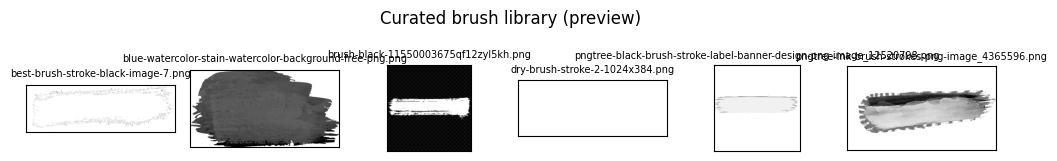

In [17]:
curated_pngs = sorted(BRUSHES_CURATED.rglob('*.png'))
if not curated_pngs:
    raise SystemExit(
        f'No PNGs under {BRUSHES_CURATED}. Curate some brushes from brushes/_raw/ first,\n'
        'then re-run the notebook from this cell.'
    )
print(f'Curated brush count: {len(curated_pngs)}')

# preview a 5x6 grid of curated brushes
preview = curated_pngs[: min(30, len(curated_pngs))]
rows = (len(preview) + 5) // 6
fig, axes = plt.subplots(rows, 6, figsize=(10, 1.6 * rows))
for ax, png in zip(axes.flat, preview):
    ax.imshow(np.array(Image.open(png).convert('L')), cmap='gray_r')
    ax.set_title(png.name, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[len(preview):]:
    ax.axis('off')
fig.suptitle('Curated brush library (preview)')
fig.tight_layout()
plt.show()

## Step 0b — Unzip Art500K `toy_dataset.zip`

Safe to re-run: skips if `toy_dataset/` already populated. This takes a while the first time (≈6.3 GB).

In [18]:
if TOY_IMG_DIR.exists() and any(TOY_IMG_DIR.iterdir()):
    n_files = sum(1 for _ in TOY_IMG_DIR.rglob('*.jpg'))
    print(f'Already extracted: {n_files} jpgs under {TOY_IMG_DIR}')
else:
    TOY_IMG_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Extracting {TOY_ZIP} -> {TOY_IMG_DIR} ...')
    with zipfile.ZipFile(TOY_ZIP) as zf:
        for info in tqdm(zf.infolist()):
            zf.extract(info, TOY_IMG_DIR)
    print('Done.')

Already extracted: 43453 jpgs under C:\Users\chell\Repos\Work\AiA-Fingerprinting\data_notcommitted\art500k\toy_dataset


In [19]:
# The extracted tree can vary; find jpgs wherever they ended up.
jpgs_sample = list(TOY_IMG_DIR.rglob('*.jpg'))[:5]
print('Sample jpg paths:')
for p in jpgs_sample:
    print('  ', p.relative_to(TOY_IMG_DIR))
total_jpgs = sum(1 for _ in TOY_IMG_DIR.rglob('*.jpg'))
print(f'Total jpgs under toy_dataset: {total_jpgs}')

Sample jpg paths:
   toy_dataset\1.jpg
   toy_dataset\10.jpg
   toy_dataset\100.jpg
   toy_dataset\1000.jpg
   toy_dataset\10000.jpg
Total jpgs under toy_dataset: 43453


## Filter metadata, sample 500 paintings

In [20]:
labels = pd.read_csv(TOY_LABEL, sep='\t')
print('labels shape:', labels.shape)
print('columns:', list(labels.columns))
labels.head(3)

labels shape: (43455, 13)
columns: ['ID', 'FILE', 'AUTHOR', 'BORN-DIED', 'TITLE', 'DATE', 'TECHNIQUE', 'LOCATION', 'FORM', 'TYPE', 'SCHOOL', 'TIMELINE', 'URL']


,ID,FILE,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,FORM,TYPE,SCHOOL,TIMELINE,URL
0,1,1.jpg,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Allegory,1598,"Oil on copper, 56 x 47 cm","Alte Pinakothek, Munich",painting,mythological,German,1601-1650,http://www.wga.hu/html/a/aachen/allegory.html
1,2,2.jpg,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)","Bacchus, Ceres and Cupid",-,"Oil on canvas, 163 x 113 cm","Kunsthistorisches Museum, Vienna",painting,mythological,German,1601-1650,http://www.wga.hu/html/a/aachen/bacchus.html
2,3,3.jpg,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Joking Couple,-,"Copperplate, 25 x 20 cm","Kunsthistorisches Museum, Vienna",painting,genre,German,1601-1650,http://www.wga.hu/html/a/aachen/j_couple.html


In [21]:
# keep paintings only, oil/tempera/watercolor/acrylic
mask_form = labels['FORM'].fillna('').str.lower().str.contains('painting')
mask_tech = labels['TECHNIQUE'].fillna('').str.contains(
    r'Oil|Tempera|Watercolor|Watercolour|Acrylic', case=False, regex=True
)
filtered = labels[mask_form & mask_tech].reset_index(drop=True)
print(f'Filtered to {len(filtered)} painterly entries')

# Filter for Impressionist/Post-Impressionist artists only
impressionist_surnames = [
    'MONET,', 'RENOIR,', 'DEGAS,', 'PISSARRO,', 'SISLEY,', 'CAILLEBOTTE,', 
    'MORISOT,', 'CASSATT,', 'BAZILLE,', 'MANET,', 'CÉZANNE,', 'GAUGUIN,',
    'VAN GOGH,', 'SEURAT,', 'SIGNAC,', 'TOULOUSE-LAUTREC,', 'GUILLAUMIN,',
    'BOUDIN,', 'GONZALÈS,'
]
mask_impressionist = filtered['AUTHOR'].apply(
    lambda x: any(x.upper().startswith(artist) for artist in impressionist_surnames) if pd.notna(x) else False
)
filtered = filtered[mask_impressionist].reset_index(drop=True)
print(f'Filtered to {len(filtered)} Impressionist entries')
print('Artists:', filtered['AUTHOR'].value_counts().head(10).to_dict())

SEED = 42
N_SAMPLES = 8
sample = filtered.sample(n=min(N_SAMPLES, len(filtered)), random_state=SEED).reset_index(drop=True)
print(f'Sampled {len(sample)} rows for synthesis')

Filtered to 23868 painterly entries
Filtered to 1073 Impressionist entries
Artists: {'MONET, Claude': 196, 'GAUGUIN, Paul': 126, 'RENOIR, Pierre-Auguste': 103, 'TOULOUSE-LAUTREC, Henri de': 103, 'CÉZANNE, Paul': 101, 'MANET, Edouard': 97, 'PISSARRO, Camille': 76, 'DEGAS, Edgar': 69, 'SISLEY, Alfred': 43, 'SEURAT, Georges': 31}
Sampled 8 rows for synthesis


In [22]:
# Resolve each row's FILE field to an actual path under TOY_IMG_DIR.
# Layout seen previously puts FILE like '1.jpg', '2.jpg', ... but there may be a subdir.
def resolve_jpg(file_name: str) -> Path | None:
    direct = TOY_IMG_DIR / file_name
    if direct.exists():
        return direct
    hits = list(TOY_IMG_DIR.rglob(file_name))
    return hits[0] if hits else None

sample['resolved_path'] = sample['FILE'].map(resolve_jpg)
missing = sample['resolved_path'].isna().sum()
print(f'Resolved {len(sample) - missing} / {len(sample)} files (missing: {missing})')
sample = sample.dropna(subset=['resolved_path']).reset_index(drop=True)

Resolved 8 / 8 files (missing: 0)


## Load the curated brush library

In [23]:
brushes = d.load_brush_library(BRUSHES_CURATED)
print(f'Loaded {len(brushes)} brushes')
print('Size range:',
      f'h∈[{min(b.height for b in brushes)}, {max(b.height for b in brushes)}]',
      f'w∈[{min(b.width for b in brushes)}, {max(b.width for b in brushes)}]')

Loaded 2 brushes
Size range: h∈[101, 360] w∈[320, 360]


c:\Users\chell\Repos\Work\AiA-Fingerprinting\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


## Synthesize 500 (painting, edge_map) pairs

Paper Algorithm 1, with light data augmentation (flip, rotate ±10°, hue jitter, mild Gaussian noise) applied to a random 30% of the outputs to diversify the training set.

In [24]:
TARGET_HW = 256
MAX_STROKES = 1500
RATIO = 0.97

train_dir = SYNTH_OUT / 'train'
val_dir   = SYNTH_OUT / 'val'
for sub in (train_dir, val_dir):
    (sub / 'paintings').mkdir(parents=True, exist_ok=True)
    (sub / 'edges').mkdir(parents=True, exist_ok=True)

def augment(painting, edge, rng):
    import colorsys
    # 50% horizontal flip
    if rng.random() < 0.5:
        painting = painting[:, ::-1].copy()
        edge = edge[:, ::-1].copy()
    # ±10° rotation
    if rng.random() < 0.4:
        ang = float(rng.uniform(-10, 10))
        pil_p = Image.fromarray((painting*255).astype(np.uint8)).rotate(ang, resample=Image.BILINEAR)
        pil_e = Image.fromarray((edge*255).astype(np.uint8)).rotate(ang, resample=Image.NEAREST)
        painting = np.array(pil_p, dtype=np.float32) / 255.0
        edge = np.array(pil_e, dtype=np.float32) / 255.0
    # hue jitter (only the painting)
    if rng.random() < 0.4:
        hsv = np.array(Image.fromarray((painting*255).astype(np.uint8)).convert('HSV'), dtype=np.float32)
        hsv[..., 0] = (hsv[..., 0] + rng.uniform(-20, 20)) % 256
        painting = np.array(Image.fromarray(hsv.astype(np.uint8), 'HSV').convert('RGB'),
                            dtype=np.float32) / 255.0
    # mild noise
    if rng.random() < 0.3:
        painting = np.clip(painting + rng.normal(0, 0.02, painting.shape), 0, 1).astype(np.float32)
    return painting, edge

rng = np.random.default_rng(SEED)
val_fraction = 0.10
val_indices = set(rng.choice(len(sample), size=int(len(sample) * val_fraction), replace=False).tolist())

errors = 0
for i, row in tqdm(sample.iterrows(), total=len(sample)):
    try:
        img = np.array(Image.open(row['resolved_path']).convert('RGB'), dtype=np.float32) / 255.0
        painting, edge, _ = d.synthesize_painting(
            img, brushes,
            target_h=TARGET_HW, target_w=TARGET_HW,
            max_strokes=MAX_STROKES, ratio_threshold=RATIO,
            seed=int(rng.integers(0, 1_000_000)),
        )
        if rng.random() < 0.3:
            painting, edge = augment(painting, edge, rng)

        out_sub = val_dir if i in val_indices else train_dir
        stem = f'{i:05d}'
        Image.fromarray((painting*255).astype(np.uint8)).save(out_sub / 'paintings' / f'{stem}.png')
        Image.fromarray((edge>0.5).astype(np.uint8)*255).save(out_sub / 'edges' / f'{stem}.png')
    except Exception as e:
        errors += 1
        if errors <= 5:
            print(f'[err {i}] {row["FILE"]}: {e}')

print(f'Done. Errors: {errors}')
print('Train pairs:', sum(1 for _ in (train_dir / 'paintings').glob('*.png')))
print('Val pairs:  ', sum(1 for _ in (val_dir / 'paintings').glob('*.png')))

100%|██████████| 8/8 [00:02<00:00,  3.15it/s]

Done. Errors: 0
Train pairs: 8
Val pairs:   0


## Sanity visualisation

Source painting vs synthesised painting vs edge map, for 8 random pairs.

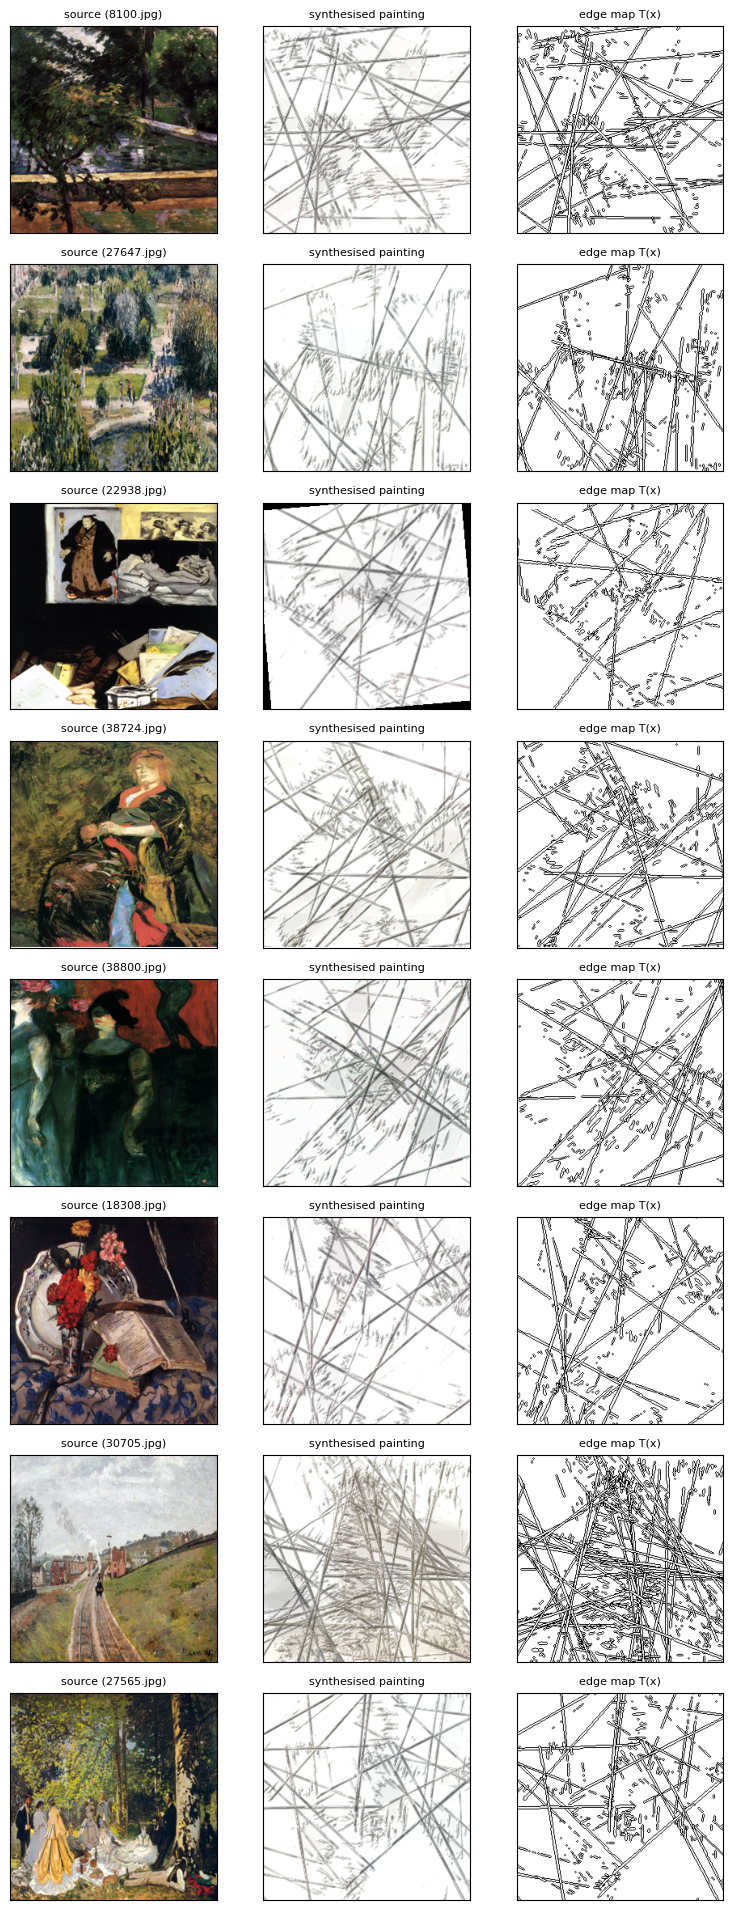

In [25]:
train_paintings = sorted((train_dir / 'paintings').glob('*.png'))
picks = random.Random(0).sample(train_paintings, k=min(8, len(train_paintings)))

fig, axes = plt.subplots(len(picks), 3, figsize=(8, 2.4 * len(picks)))
for ax_row, p in zip(axes, picks):
    stem = p.stem
    edge_path = train_dir / 'edges' / f'{stem}.png'
    idx = int(stem)
    src_path = sample.iloc[idx]['resolved_path']
    src = Image.open(src_path).convert('RGB').resize((TARGET_HW, TARGET_HW))
    paint = Image.open(p)
    edge = Image.open(edge_path)
    ax_row[0].imshow(src); ax_row[0].set_title(f'source ({Path(src_path).name})', fontsize=8)
    ax_row[1].imshow(paint); ax_row[1].set_title('synthesised painting', fontsize=8)
    ax_row[2].imshow(edge, cmap='gray_r'); ax_row[2].set_title('edge map T(x)', fontsize=8)
    for a in ax_row:
        a.set_xticks([]); a.set_yticks([])
fig.tight_layout()
plt.show()

---

Dataset synthesis complete. Next notebooks consume:

- `data_notcommitted/dstroke_synth/train/paintings/*.png` — input for GAN/SegFormer generator
- `data_notcommitted/dstroke_synth/train/edges/*.png` — target edge map ground truth
- `data_notcommitted/dstroke_synth/val/*` — held-out pairs for `03_strategy_comparison.ipynb`

In [ ]:
import cv2
import numpy as np
from skimage.morphology import skeletonize
from skimage.filters import frangi

def extract_line_skeleton(image_path, method='frangi'):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Enhance line structures using Frangi vesselness filter
    # This responds to ridge-like (line-like) structures
    # and is parameterized by expected line width (sigma range)
    enhanced = frangi(
        img,
        sigmas=range(1, 6),     # line widths in pixels
        black_ridges=True,       # dark lines on light background
    )
    
    # Threshold to binary
    binary = enhanced > np.percentile(enhanced, 85)
    
    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    
    # Skeletonize: reduce each line region to a 1px-wide skeleton
    skeleton = skeletonize(binary > 0)
    
    return skeleton, binary, enhanced